<a href="https://colab.research.google.com/github/THARIK-ASAN2003/THARIK-ASAN2003/blob/main/LIGHT_GBM_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install lightgbm

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import RobustScaler, LabelEncoder
import lightgbm as lgb
import warnings
import json
warnings.filterwarnings('ignore')

In [7]:
# Set random seed for reproducibility
np.random.seed(42)

In [8]:
# Load the data
train = pd.read_csv('/content/Railofy_training_data_for_model.csv')
test = pd.read_csv("/content/Railofy_testing_data_for_model.csv")


In [9]:
# Null value check function
def check_null_values(df, dataset_name):
    print(f"\nNull Value Check for {dataset_name}:")
    null_counts = df.isna().sum()
    null_percentages = (df.isna().sum() / len(df)) * 100
    null_info = pd.DataFrame({
        'Null Count': null_counts,
        'Null Percentage': null_percentages
    })
    null_info = null_info[null_info['Null Count'] > 0]
    if len(null_info) > 0:
        print(null_info)
    else:
        print("No null values found!")
    return null_info

In [10]:
# Handle null values function
def handle_null_values(df):
    df_clean = df.copy()
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_columns:
        if df[col].isna().sum() > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    categorical_columns = df.select_dtypes(include=['object']).columns
    for col in categorical_columns:
        if df[col].isna().sum() > 0:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    return df_clean

In [11]:
# Check and handle null values
train_nulls = check_null_values(train, "Training Data")
test_nulls = check_null_values(test, "Test Data")

if len(train_nulls) > 0:
    train_clean = handle_null_values(train)
else:
    train_clean = train

if len(test_nulls) > 0:
    test_clean = handle_null_values(test)
else:
    test_clean = test


Null Value Check for Training Data:
No null values found!

Null Value Check for Test Data:
No null values found!


In [12]:
# Verify null values handled
print("\nVerifying null values after handling:")
check_null_values(train_clean, "Cleaned Training Data")
check_null_values(test_clean, "Cleaned Test Data")



Verifying null values after handling:

Null Value Check for Cleaned Training Data:
No null values found!

Null Value Check for Cleaned Test Data:
No null values found!


,Null Count,Null Percentage


In [13]:
# Data preprocessing function
def preprocess_data(train_df, test_df, target_column='target'):
    if target_column in train_df.columns:
        y = train_df[target_column].copy()
        X = train_df.drop(columns=[target_column])
    else:
        y = None
        X = train_df.copy()

    X_test = test_df.copy()
    numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns
    categorical_columns = X.select_dtypes(include=['object']).columns
    rb_scaler = RobustScaler()
    label_encoders = {}

    if len(numeric_columns) > 0:
        X_numeric = pd.DataFrame(rb_scaler.fit_transform(X[numeric_columns]),
                                columns=numeric_columns,
                                index=X.index)
        X_test_numeric = pd.DataFrame(rb_scaler.transform(X_test[numeric_columns]),
                                     columns=numeric_columns,
                                     index=X_test.index)
    else:
        X_numeric = pd.DataFrame(index=X.index)
        X_test_numeric = pd.DataFrame(index=X_test.index)

    X_categorical = pd.DataFrame(index=X.index)
    X_test_categorical = pd.DataFrame(index=X_test.index)

    for col in categorical_columns:
        le = LabelEncoder()
        X_categorical[col] = le.fit_transform(X[col])
        X_test_categorical[col] = le.transform(X_test[col])
        label_encoders[col] = le

    X_processed = pd.concat([X_numeric, X_categorical], axis=1)
    X_test_processed = pd.concat([X_test_numeric, X_test_categorical], axis=1)

    return X_processed, X_test_processed, y, label_encoders


In [14]:
# Apply preprocessing
X_processed, X_test_processed, y, label_encoders = preprocess_data(train_clean, test_clean)


In [15]:
# Split the data
X_train, X_valid, y_train, y_valid = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=2021
)

print("Dataset shapes after preprocessing:")
print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"X_test: {X_test_processed.shape}")

Dataset shapes after preprocessing:
X_train: (29420, 24)
X_valid: (7355, 24)
X_test: (3847, 24)


In [16]:
# Train LightGBM model
lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.01,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1  # Suppress LightGBM's own verbosity
}
lgb_train = lgb.Dataset(X_train, y_train)
lgb_valid = lgb.Dataset(X_valid, y_valid, reference=lgb_train)


In [17]:
# Create callbacks for early stopping and logging
early_stop = lgb.early_stopping(stopping_rounds=100)

def log_evaluation(period=100):
    def callback(env):
        if (env.iteration + 1) % period == 0:
            print(f'Iteration {env.iteration + 1}, validation binary_logloss: {env.evaluation_result_list[1][2]:.5f}')
    callback.order = 0
    return callback

In [18]:
#Train the model
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=10000,
    valid_sets=[lgb_train, lgb_valid],
    callbacks=[early_stop, log_evaluation(100)]
)

Training until validation scores don't improve for 100 rounds
Iteration 100, validation binary_logloss: 0.48478
Iteration 200, validation binary_logloss: 0.43794
Iteration 300, validation binary_logloss: 0.41167
Iteration 400, validation binary_logloss: 0.39204
Iteration 500, validation binary_logloss: 0.37773
Iteration 600, validation binary_logloss: 0.36657
Iteration 700, validation binary_logloss: 0.35709
Iteration 800, validation binary_logloss: 0.34860
Iteration 900, validation binary_logloss: 0.34176
Iteration 1000, validation binary_logloss: 0.33539
Iteration 1100, validation binary_logloss: 0.32869
Iteration 1200, validation binary_logloss: 0.32276
Iteration 1300, validation binary_logloss: 0.31741
Iteration 1400, validation binary_logloss: 0.31293
Iteration 1500, validation binary_logloss: 0.30818
Iteration 1600, validation binary_logloss: 0.30333
Iteration 1700, validation binary_logloss: 0.29906
Iteration 1800, validation binary_logloss: 0.29491
Iteration 1900, validation bi

In [19]:
# Make predictions
val_pred = lgb_model.predict(X_valid, num_iteration=lgb_model.best_iteration)
val_pred_binary = (val_pred > 0.5).astype(int)
test_pred = lgb_model.predict(X_test_processed, num_iteration=lgb_model.best_iteration)


In [20]:
# Create submission file
submission_file = pd.DataFrame()
submission_file['pk'] = test['pk']
submission_file['target'] = test_pred
submission_file.to_csv('submission.csv', index=False)

print("\nSubmission file created successfully!")
print("\nSubmission Preview:")
print(submission_file.head())


Submission file created successfully!

Submission Preview:
           pk    target
0  8831606085  0.058463
1  8831561565  0.011929
2  8831539811  0.723855
3  8831313791  0.357514
4  8831070109  0.031751


In [21]:
# Model Evaluation and Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [22]:
# Create evaluation plots
plt.figure(figsize=(20, 15))

<Figure size 2000x1500 with 0 Axes>

<Figure size 2000x1500 with 0 Axes>

Text(0.5, 229.98333333333335, 'Predicted Label')

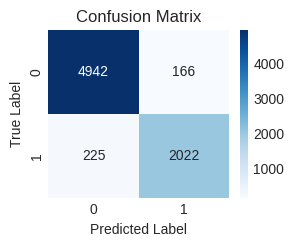

In [23]:
# Confusion Matrix
plt.subplot(2, 2, 1)
cm = confusion_matrix(y_valid, val_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

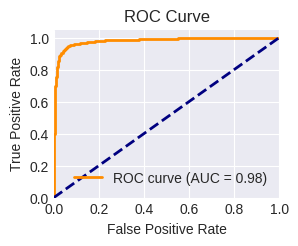

In [24]:
# ROC Curve
plt.subplot(2, 2, 2)
fpr, tpr, _ = roc_curve(y_valid, val_pred)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

Text(0.5, 1.0, 'Precision-Recall Curve')

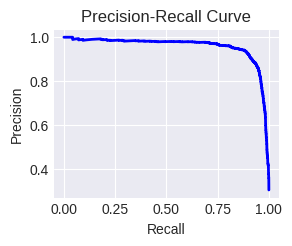

In [25]:
# Precision-Recall Curve
plt.subplot(2, 2, 3)
precision, recall, _ = precision_recall_curve(y_valid, val_pred)
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')


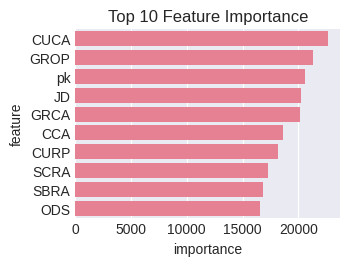

In [26]:
# Feature Importance
plt.subplot(2, 2, 4)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importance()
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Feature Importance')

plt.tight_layout()
plt.show()

In [27]:
# Print model performance metrics
print("\nModel Performance Metrics:")
print("\nClassification Report:")
print(classification_report(y_valid, val_pred_binary))
print(f"\nAccuracy Score: {accuracy_score(y_valid, val_pred_binary):.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")



Model Performance Metrics:

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      5108
           1       0.92      0.90      0.91      2247

    accuracy                           0.95      7355
   macro avg       0.94      0.93      0.94      7355
weighted avg       0.95      0.95      0.95      7355


Accuracy Score: 0.9468
ROC AUC Score: 0.9793


In [28]:
# Access the average precision score (or a specific value) instead of the entire array
print(f"Precision Score: {precision.mean():.4f}")  # Using mean for average precision
print(f"Recall Score: {recall.mean():.4f}")  # Using mean for average recall


Precision Score: 0.6533
Recall Score: 0.8328


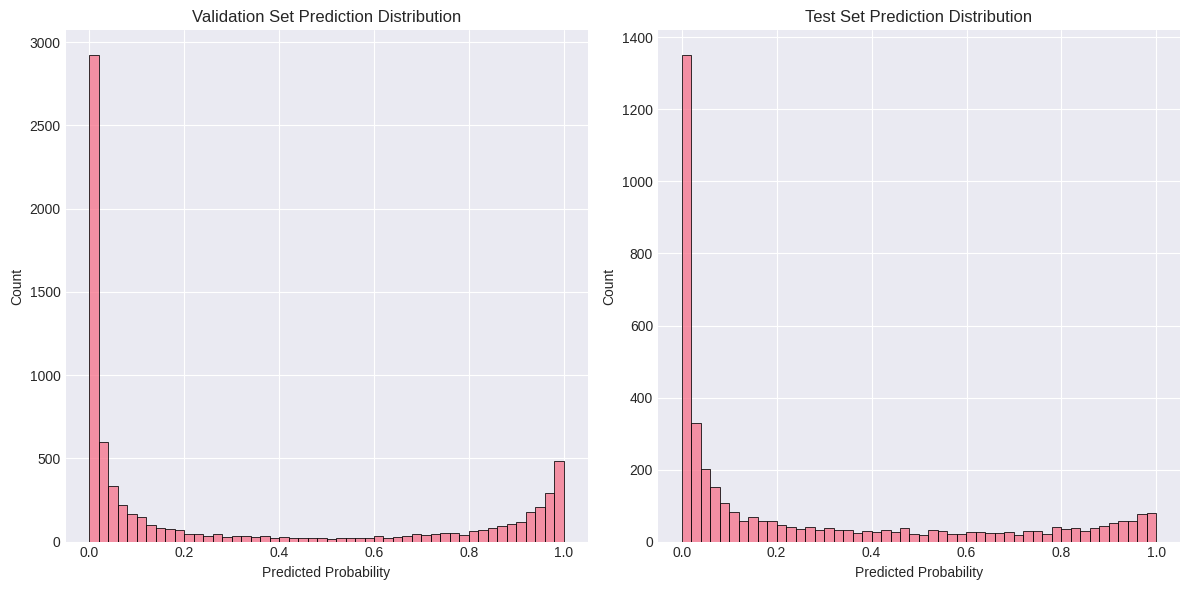

In [29]:
# Prediction Distribution Analysis
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(val_pred, bins=50)
plt.title('Validation Set Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(test_pred, bins=50)
plt.title('Test Set Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [30]:
# Save analysis results
analysis_results = {
    'model_accuracy': accuracy_score(y_valid, val_pred_binary),
    'roc_auc': roc_auc,
    'feature_importance': feature_importance.head(10).to_dict(),
    'confusion_matrix': cm.tolist()
}

with open('model_analysis_results.json', 'w') as f:
    json.dump(analysis_results, f)

print("\nAnalysis completed and results saved!")
print(f"Final Model Accuracy: {analysis_results['model_accuracy']:.4f}")
print(f"ROC AUC Score: {analysis_results['roc_auc']:.4f}")


Analysis completed and results saved!
Final Model Accuracy: 0.9468
ROC AUC Score: 0.9793
